#Importacion de liberarias

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

#ETL

In [87]:
# -----------------------------------------------------------------------------
# 1. ETL
# -----------------------------------------------------------------------------
url="https://raw.githubusercontent.com/No-Country-simulation/Hackaton_G9_Server_2_Team27/refs/heads/main/data/dataset_bruto_final.csv"
df=pd.read_csv(url)

#Eliminar consumos incoherentes
df.drop(df[df["consumo_kwh"] > 4000].index, inplace=True)
df.drop(df[
    (df["cantidad_equipos"] <= 5) &
    (df["consumo_kwh"] > 2500)
].index, inplace=True)


#Variables para el modelo
#Hallazgo: "La variable uso_horario_pico fue recibida por compatibilidad con la especificación del endpoint,
#pero no fue utilizada en el modelo debido a que presentaba un único valor en el conjunto de entrenamiento."

df_model = df[[
    "tipo_vivienda",
    "cantidad_equipos",
    "horas_alto_consumo",
    "consumo_kwh",
    "categoria"
]].copy()

df_model.to_csv("dataset_model_knn.csv", index=False)


#MODELADO

In [88]:

# -----------------------------------------------------------------------------
# 2. ESTRUCUTRA DE DATOS
# -----------------------------------------------------------------------------

print("--- Resumen del Dataset ---")
print(f"Dimensiones: {df_model.shape}")
print(df_model.info())



--- Resumen del Dataset ---
Dimensiones: (9992, 5)
<class 'pandas.core.frame.DataFrame'>
Index: 9992 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tipo_vivienda       9992 non-null   object 
 1   cantidad_equipos    9992 non-null   int64  
 2   horas_alto_consumo  9992 non-null   int64  
 3   consumo_kwh         9992 non-null   float64
 4   categoria           9992 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 468.4+ KB
None


In [89]:
# -----------------------------------------------------------------------------
# 3. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# -----------------------------------------------------------------------------
# Crear métricas de consumo relativo para ayudar a KNN a capturar patrones
df_model['consumo_por_equipo'] = (
    df_model['consumo_kwh'] / (df_model['cantidad_equipos'].replace(0,1))
)
df_model['consumo_por_hora_alta'] = (
    df_model['consumo_kwh'] / (df_model['horas_alto_consumo'] + 1e-5)
)

# Separación de características (X) y etiqueta objetivo (y)
X = df_model.drop("categoria", axis=1)
y = df_model["categoria"]

# Codificación de variables categóricas (One-Hot Encoding)
X = pd.get_dummies(X, columns=["tipo_vivienda"], drop_first=True)

# Guardar el orden de las columnas del modelo
columnas_modelo = X.columns.tolist()

joblib.dump(columnas_modelo, "columnas_modelo.pkl")



['columnas_modelo.pkl']

In [90]:
# -----------------------------------------------------------------------------
# 4. DIVISIÓN DEL DATASET Y ESCALADO ROBUSTO
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# RobustScaler es resistente a outliers en el consumo de kWh
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [91]:
# -----------------------------------------------------------------------------
# 5. BÚSQUEDA Y OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)
# -----------------------------------------------------------------------------
# Probar valores impares de k para evitar empates, junto con métricas y pesos
param_grid = {
    'n_neighbors': list(range(3, 31, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_base = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n--- Ejecutando Búsqueda de Hiperparámetros ---")
grid_search.fit(X_train_scaled, y_train)

best_knn = grid_search.best_estimator_
print(f"\nMejores Parámetros Encontrados: {grid_search.best_params_}")
print(f"Mejor Accuracy en CV (Entrenamiento): {grid_search.best_score_:.4f}")




--- Ejecutando Búsqueda de Hiperparámetros ---
Fitting 5 folds for each of 84 candidates, totalling 420 fits

Mejores Parámetros Encontrados: {'metric': 'manhattan', 'n_neighbors': 29, 'weights': 'uniform'}
Mejor Accuracy en CV (Entrenamiento): 0.4685


In [92]:
# -----------------------------------------------------------------------------
# 6. EVALUACIÓN DEL MODELO EN EL CONJUNTO DE PRUEBA
# -----------------------------------------------------------------------------
y_pred = best_knn.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Resultados en Test ---")
print(f"Accuracy Final: {test_accuracy:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))




--- Resultados en Test ---
Accuracy Final: 0.4587

Reporte de Clasificación:
              precision    recall  f1-score   support

   Efficient       0.44      0.35      0.39       600
 Inefficient       0.46      0.33      0.39       500
    Moderate       0.46      0.60      0.52       899

    accuracy                           0.46      1999
   macro avg       0.46      0.43      0.43      1999
weighted avg       0.46      0.46      0.45      1999



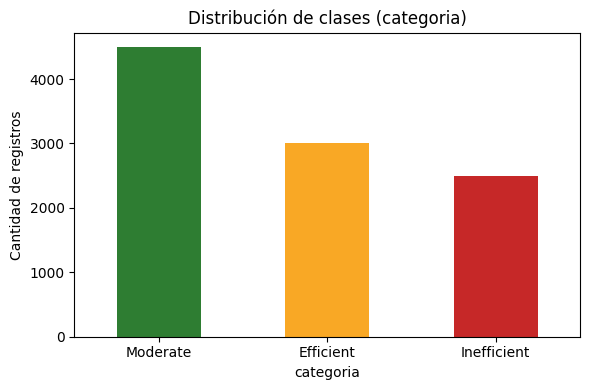

In [93]:
# =============================================================================
# 7. VISUALIZACIONES
# =============================================================================

# 7.1 Balance de clases
fig, ax = plt.subplots(figsize=(6, 4))
df["categoria"].value_counts().plot(kind="bar", color=["#2E7D32", "#F9A825", "#C62828"], ax=ax)
ax.set_title("Distribución de clases (categoria)")
ax.set_ylabel("Cantidad de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

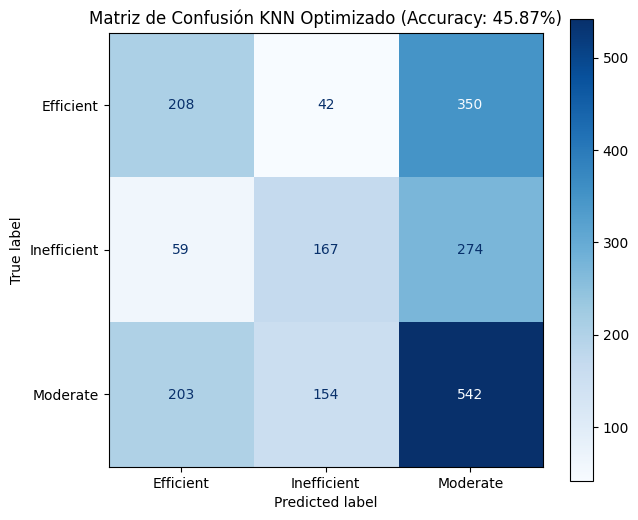

In [94]:
#7.2 # Visualización de la Matriz de Confusión
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    ax=ax
)
plt.title(f"Matriz de Confusión KNN Optimizado (Accuracy: {test_accuracy:.2%})")
plt.grid(False)
plt.show()

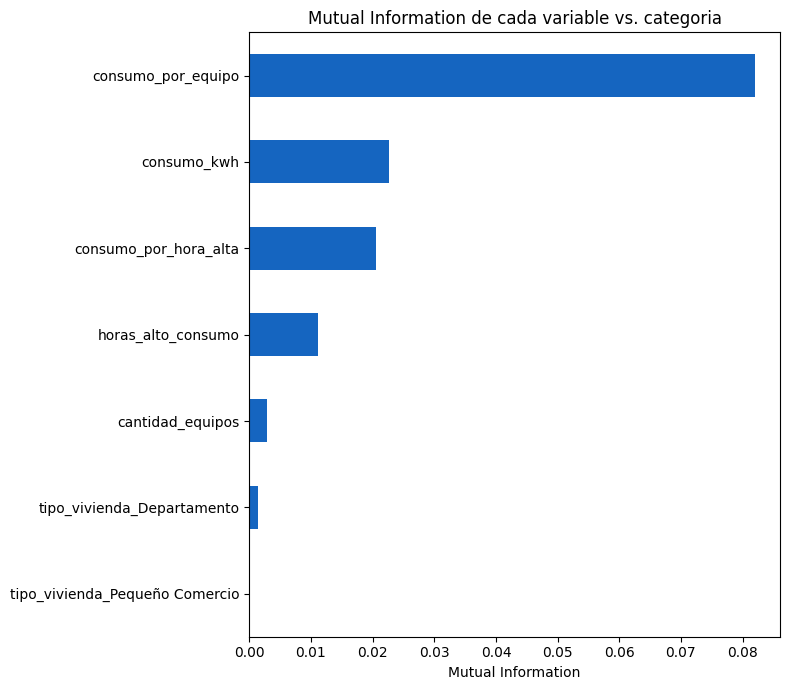

In [95]:
#7.3 Mutual information ranking
fig, ax = plt.subplots(figsize=(8, 7))
mi_ranking.sort_values().plot(kind="barh", color="#1565C0", ax=ax)
ax.set_title("Mutual Information de cada variable vs. categoria")
ax.set_xlabel("Mutual Information")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


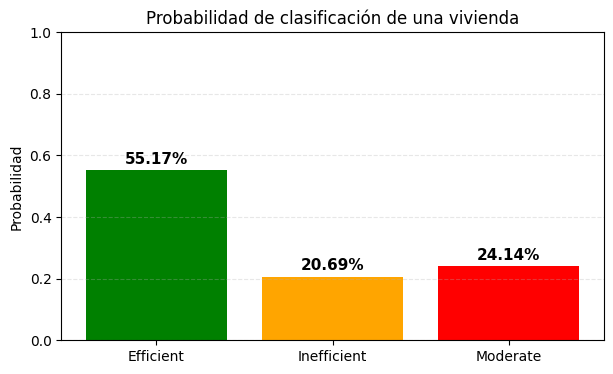

In [96]:
#7.4 Probabilidad de prediccion

proba = knn.predict_proba(X_test[:1])[0]

colores = ["green", "orange", "red"]

plt.figure(figsize=(7,4))

bars = plt.bar(
    knn.classes_,
    proba,
    color=colores
)

plt.ylim(0,1)

plt.ylabel("Probabilidad")
plt.title("Probabilidad de clasificación de una vivienda")

for bar, valor in zip(bars, proba):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        valor + 0.02,
        f"{valor:.2%}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

#Conclusión del modelo KNN

Se implementó un modelo de clasificación K-Nearest Neighbors (KNN) con el objetivo de predecir la categoría de eficiencia energética de una vivienda (Eficiente, Moderado o Ineficiente) a partir de las variables disponibles en el conjunto de datos. Antes del entrenamiento se realizó un proceso de limpieza y preparación de los datos, eliminando variables que no aportaban información al modelo, como identificadores, variables derivadas (costo_estimado) y variables con valor constante (uso_horario_pico), además de codificar las variables categóricas y escalar las variables numéricas, ya que KNN es un algoritmo basado en distancias.

Posteriormente, se dividió el conjunto de datos en entrenamiento y prueba, se entrenó el modelo y se evaluó mediante métricas como Accuracy, Precision, Recall, F1-Score y la Matriz de Confusión. Estas métricas permitieron analizar la capacidad del modelo para clasificar correctamente las viviendas según su nivel de eficiencia energética.

Es importante destacar que el dataset presenta algunas limitaciones, como variables con poca variabilidad y una fuerte relación entre la variable objetivo (categoria) y el energy_efficiency_score, por lo que se evitó utilizar esta última durante el entrenamiento para prevenir fuga de información (data leakage). De esta forma, el modelo aprende únicamente a partir de las variables que estarán disponibles cuando el usuario realice una consulta al sistema.

En conclusión, KNN es un modelo adecuado como línea base para este problema de clasificación, debido a su simplicidad e interpretabilidad. Sin embargo, su desempeño depende en gran medida de la calidad de los datos y de la representatividad de las variables utilizadas.

Se recomienda comparar sus resultados con otros algoritmos como Random Forest, XGBoost o Gradient Boosting, que suelen ofrecer un mejor desempeño cuando existen relaciones complejas entre las variables y datos con características heterogéneas.

#Serializacion

In [97]:
# -----------------------------------------------------------------------------
# 8. SERIALIZACION DEL MODELO
# -----------------------------------------------------------------------------

# Mejor modelo encontrado por GridSearchCV
knn = grid_search.best_estimator_

# Guardar el modelo
joblib.dump(knn, "modelo_knn.pkl")

# Guardar el escalador
joblib.dump(scaler, "scaler.pkl")

# Guardar columnas del entrenamiento
columnas_modelo = X.columns.tolist()
joblib.dump(columnas_modelo, "columnas_modelo.pkl")

print("Modelo, scaler y columnas guardados correctamente.")


Modelo, scaler y columnas guardados correctamente.


In [98]:
# ==========================================================
# 9. VERIFICAR QUE EL MODELO SE GUARDÓ
# ==========================================================

modelo = joblib.load("modelo_knn.pkl")

scaler = joblib.load("scaler.pkl")

print(modelo)
print(scaler)

KNeighborsClassifier(metric='manhattan', n_neighbors=29)
RobustScaler()
